# Predicted vs Actual Cost — Scatter Plot

In [6]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath('..'))

import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import method.absolute_cost_estimator as _ace_mod
importlib.reload(_ace_mod)
from method.absolute_cost_estimator import AbsoluteCostEstimator

In [7]:
# Config
DATA_DIR = "../data/consolidated"
K = 5
TEST_RATIO = 0.2
SEED = 42

with open("../apikey.json") as f:
    api_keys = json.load(f)
API_KEY = api_keys["gemini_api_key"]

with open("../constant/experiment_config.json") as f:
    exp_config = json.load(f)
MODELS = [m["model_name"] for m in exp_config["models"]]
DATASETS = [d["file_prefix"] for d in exp_config["datasets"]]

with open("../constant/model_info.json") as f:
    model_info = json.load(f)
short_names = {m["model_name"]: m["short_name"] for m in model_info["models"]}

# Build index
estimator = AbsoluteCostEstimator(
    models=MODELS, embedding_provider="gemini", api_key=API_KEY, k=K,
)
estimator.build_index(data_dir=DATA_DIR, datasets=DATASETS)
print(estimator)

AbsoluteCostEstimator(models=8, provider='gemini', k=5, index=built, n_queries=11476)


In [8]:
# Train/test split + KNN median predictions
train_idx, test_idx = estimator.train_test_split(TEST_RATIO, SEED)
train_embs = estimator._embeddings[train_idx]
train_costs = estimator._costs[train_idx]
test_embs = estimator._embeddings[test_idx]
test_costs = estimator._costs[test_idx]

sim_matrix = estimator._cosine_similarity(test_embs, train_embs)
k = min(K, len(train_idx))

knn_med_pred = np.zeros_like(test_costs)
for i in range(len(test_idx)):
    sims = sim_matrix[i]
    top_k = np.argsort(sims)[-k:][::-1]
    knn_med_pred[i] = np.median(train_costs[top_k], axis=0)

print(f"Test set: {len(test_idx)} queries, {len(estimator.model_list)} models")

Test set: 2295 queries, 8 models


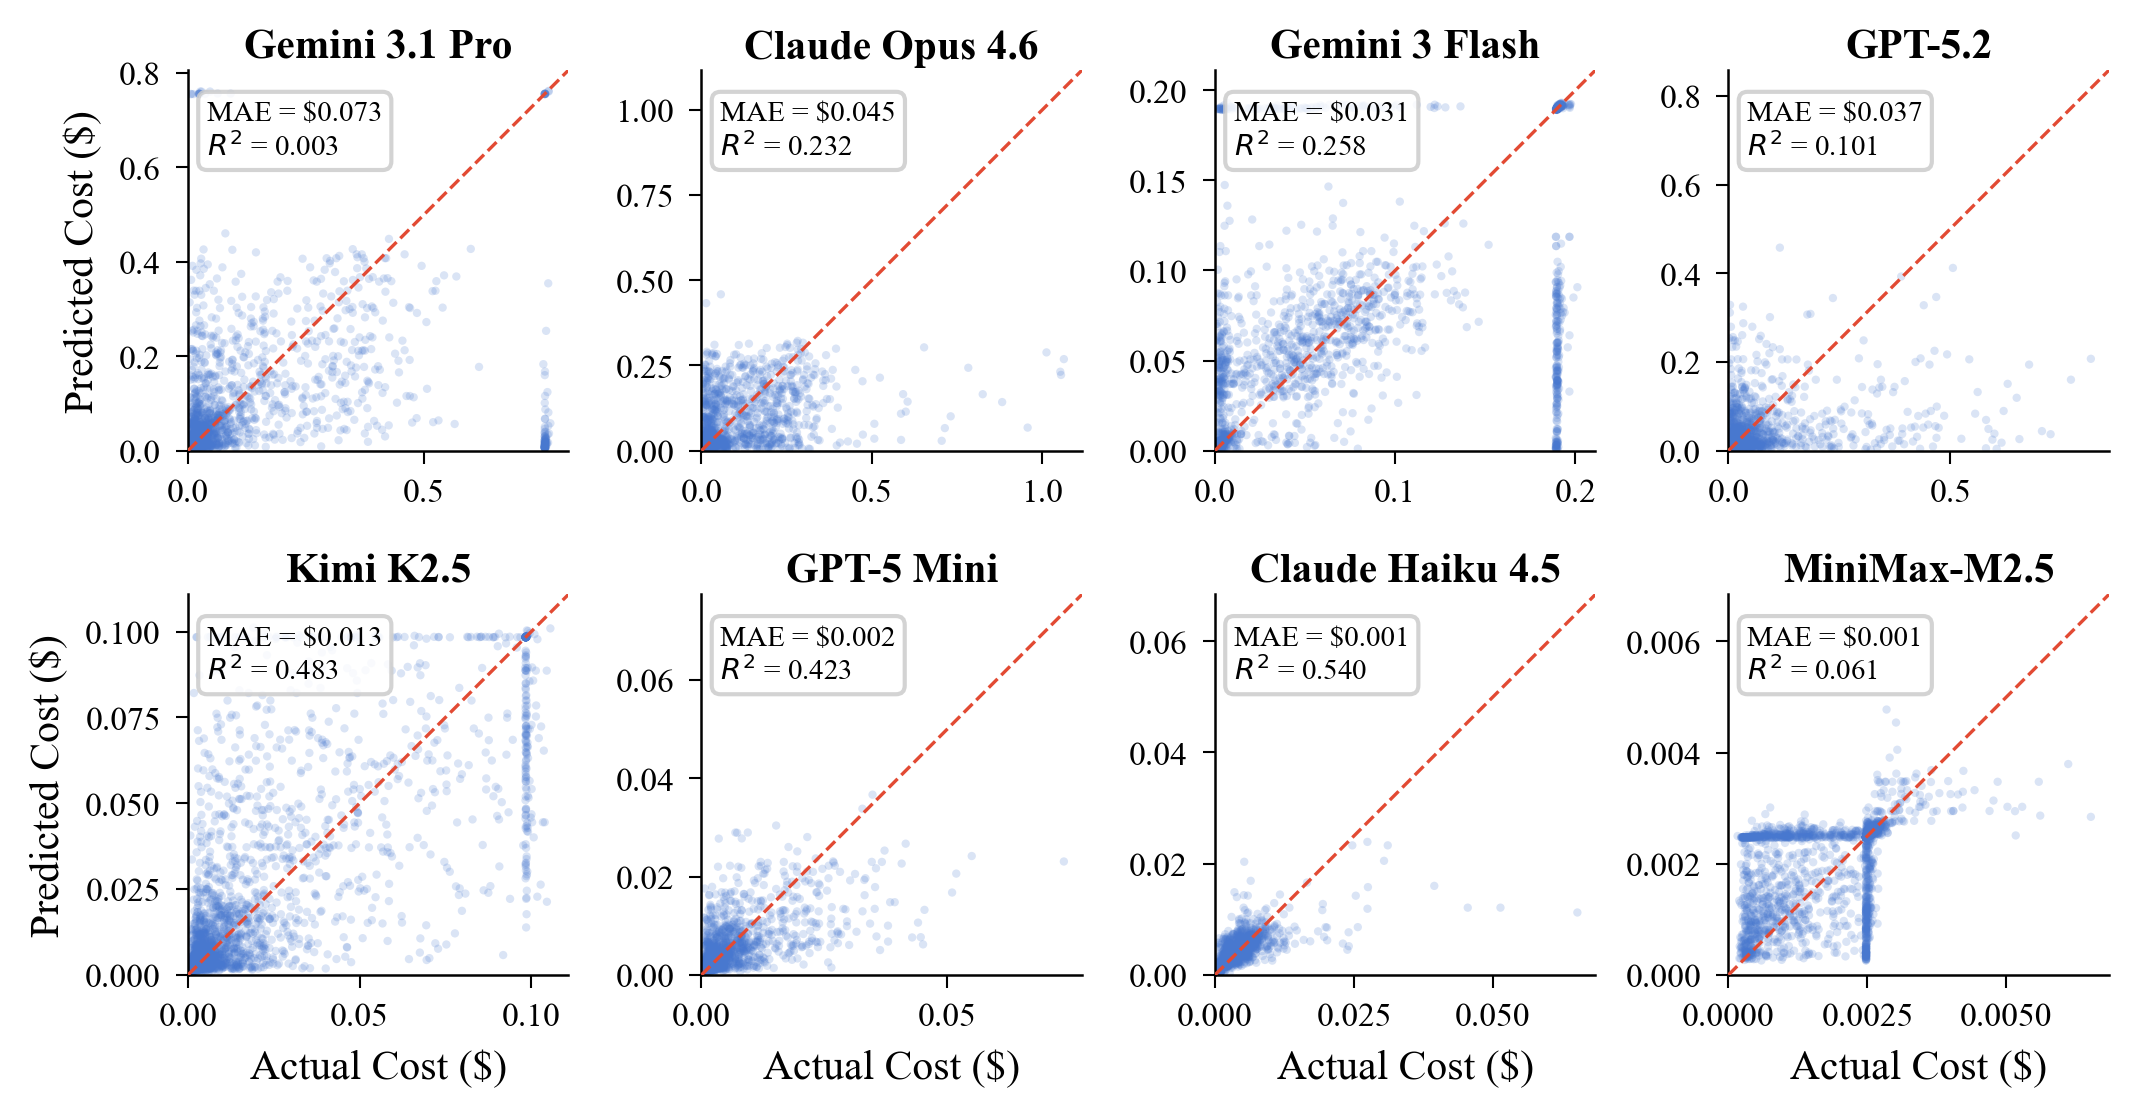

Saved to figure/predicted_vs_actual_cost.pdf


In [9]:
# Publication-quality scatter plot: Predicted vs Actual Cost
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
})

fig, axes = plt.subplots(2, 4, figsize=(7.2, 3.8))  # ~double-column width
axes = axes.flatten()

# Order models by descending average cost for better visual flow
avg_costs = test_costs.mean(axis=0)
order = np.argsort(-avg_costs)

for plot_idx, idx in enumerate(order):
    ax = axes[plot_idx]
    model = estimator.model_list[idx]
    act = test_costs[:, idx]
    pred = knn_med_pred[:, idx]

    ax.scatter(act, pred, alpha=0.2, s=4, c='#4878CF', edgecolors='none', rasterized=True)

    # y=x reference line
    lo = 0
    hi = max(act.max(), pred.max()) * 1.05
    ax.plot([lo, hi], [lo, hi], color='#E24A33', ls='--', lw=0.8, zorder=5)

    # Stats
    _mae = np.mean(np.abs(pred - act))
    _r2 = 1 - np.sum((act - pred)**2) / np.sum((act - act.mean())**2)

    name = short_names.get(model, model)
    ax.set_title(name, fontweight='bold', pad=3)
    ax.text(0.05, 0.92, f'MAE = ${_mae:.3f}\n$R^2$ = {_r2:.3f}',
            transform=ax.transAxes, fontsize=7, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cccccc', alpha=0.85))

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')

    # Only show axis labels on edges
    if plot_idx >= 4:
        ax.set_xlabel('Actual Cost (\\$)')
    if plot_idx % 4 == 0:
        ax.set_ylabel('Predicted Cost (\\$)')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(w_pad=0.8, h_pad=1.2)
plt.savefig("../figure/predicted_vs_actual_cost.pdf", bbox_inches='tight', dpi=300)
plt.show()
print("Saved to figure/predicted_vs_actual_cost.pdf")